In [ ]:
# Jeremy Mamaril
# Youtube Trending Video Engagement Benchmarker
# DTSC 691 Machine Learning Capstone

"\nPurpose:\nThis model was trained on YouTube trending videos from the US, Canada,\nand Mexico, sourced from the Kaggle YouTube Trending Videos\ndataset.\n\nBecause the dataset contains only videos that reached YouTube's trending\npage, the model benchmarks a video's pre-upload metadata against trending\ncontent specifically — not against all YouTube videos. Trending videos\nrepresent the top-performing content on the platform, so the comparison\nis intentionally a high bar.\n\nGiven pre-upload metadata, the model predicts how a video's engagement rate would\nlikely compare to other trending videos, using patterns learned from\ncontent that successfully trended in North America.\n\nThis is useful for creators who want to understand whether their content\nsetup aligns with patterns seen in high-engagement trending videos.\n"

## Imports and Settings

In [ ]:
import sys

assert sys.version_info >= (3, 8)

In [ ]:
# Import all required modules
import numpy as np
import pandas as pd

# Plotting modules
import matplotlib.pyplot as plt
import seaborn as sns

# Model preparation and creation modules
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

# Model creation and evaluation modules
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, root_mean_squared_error, mean_absolute_error, r2_score

# Neural network modules
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Miscellaneous imports
from datetime import datetime
import pickle as pkl
import json

## Load and Put Together Datasets

In [ ]:
# Load the datasets and tag each with its country
youtube_videos_usa    = pd.read_csv("USvideos.csv", encoding='utf-8').sample(n=17000, random_state=42)
youtube_videos_canada = pd.read_csv("CAvideos.csv", encoding='utf-8').sample(n=17000, random_state=42)
youtube_videos_mexico = pd.read_csv("MXvideos.csv", encoding='latin-1').sample(n=17000, random_state=42)

youtube_videos_usa['country']    = 'US'
youtube_videos_canada['country'] = 'CA'
youtube_videos_mexico['country'] = 'MX'

youtube_videos = pd.concat([youtube_videos_usa, youtube_videos_canada, youtube_videos_mexico])
youtube_videos.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country
15632,ugdgAifIOBA,18.02.02,Why Don't We - Trust Fund Baby (Official Audio),Atlantic Records,10,2018-02-01T05:01:03.000Z,"music|""official""|""music video""|""atlantic""|""rec...",206028,21951,329,2951,https://i.ytimg.com/vi/ugdgAifIOBA/default.jpg,False,False,False,'Trust Fund Baby' Out Now:\nhttps://Atlantic.l...,US
40759,Gi56dSh8Fq8,18.14.06,Gourmet Chef Makes A Big Mac Super Fancy,BuzzFeedVideo,22,2018-06-13T18:00:32.000Z,"mcdonalds|""big mac""|""fancy""|""fast food""|""jacqu...",402418,10070,3303,2142,https://i.ytimg.com/vi/Gi56dSh8Fq8/default.jpg,False,False,False,"It's your good ol' McDonald's Big Mac, but lik...",US
10536,7VnEPIBsp20,18.05.01,Zac Efron Made Michael Jackson Cry! | The Grah...,The Graham Norton Show,24,2017-12-29T15:30:01.000Z,"Graham Norton|""Graham Norton Show Official""|""E...",1437372,33670,1626,2233,https://i.ytimg.com/vi/7VnEPIBsp20/default.jpg,False,False,False,Dreams do come true...\nSubscribe for weekly u...,US
11029,vvuj7-xspns,18.08.01,JuJu Smith-Schuster Pranks Steelers Fans - Und...,JuJu Smith-Schuster,24,2018-01-05T18:59:22.000Z,"JuJu Smith-Schuster|""JuJu Smith""|""JuJu""|""JuJu ...",417790,13878,346,2000,https://i.ytimg.com/vi/vvuj7-xspns/default.jpg,False,False,False,I took over the streets as John Smith from WXW...,US
8202,0ycLaWymtKk,17.25.12,Merry Christmas in Dominoes! 🎅🏻 (Christmas Card),Hevesh5,24,2017-12-23T18:00:00.000Z,"christmas|""christmas domino""|""merry christmas""...",816662,16873,468,1038,https://i.ytimg.com/vi/0ycLaWymtKk/default.jpg,False,False,False,Merry Christmas! Share this Christmas card wit...,US


## Data Cleaning and Preprocessing

In [ ]:
# View Youtube Videos In Reverse Alphabetical Order to Check for Bad Characters
youtube_videos.sort_values(by='title', ascending=False)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country
27838,Az72jrKbANA,18.04.04,🚨Active Shooter at YouTube Headquarters - LIVE...,Right Side Broadcasting Network,25,2018-04-03T23:12:37.000Z,"YouTube shooter|""YouTube active shooter""|""acti...",103513,1722,181,76,https://i.ytimg.com/vi/Az72jrKbANA/default.jpg,False,False,False,An active shooter has been reported at the You...,CA
31731,WttN1Z0XF4k,18.30.04,😲She Is So Nervous But BLOWS The ROOF After Ta...,How Talented,24,2018-04-28T19:40:58.000Z,"bgt|""bgt 2018""|""britain got talent""|""britain´s...",476253,3417,176,240,https://i.ytimg.com/vi/WttN1Z0XF4k/default.jpg,False,False,False,Amy Marie Borg - Britain´s Got Talent 2018\n\n...,CA
31524,WttN1Z0XF4k,18.29.04,😲She Is So Nervous But BLOWS The ROOF After Ta...,How Talented,24,2018-04-28T19:40:58.000Z,"bgt|""bgt 2018""|""britain got talent""|""britain´s...",231906,1924,78,146,https://i.ytimg.com/vi/WttN1Z0XF4k/default.jpg,False,False,False,Amy Marie Borg - Britain´s Got Talent 2018\n\n...,CA
16144,r3J784MSRyQ,18.04.02,"😱 $1,145 iPhone Case!!",iJustine,28,2018-02-02T23:33:00.000Z,"ijustine|""gray international""|""most expensive ...",408713,15040,2038,2617,https://i.ytimg.com/vi/r3J784MSRyQ/default.jpg,False,False,False,What do you guys thing of this iPhone Case?!\n...,CA
22803,97FMj5OA31E,18.10.03,🔴안희정에게 돌직구 날린 그녀 누군가 했더니..충격..🔵,리얼스토리TV,24,2018-03-09T10:26:54.000Z,"안희정|""조정린""",1446673,2355,1188,809,https://i.ytimg.com/vi/97FMj5OA31E/default.jpg,False,False,False,지난 9일 서부지검 앞\n안희정 전 지사의\n자친출두를 앞두고 \n\n수많은 카메라...,CA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14575,jagKN9spZn8,18.27.01,!!MISHELL SORPRENDIO A TODOS CON ESTAS FOTOS!!,Kozmo HD,24,2018-01-26T03:21:21.000Z,[none],177138,735,66,91,https://i.ytimg.com/vi/jagKN9spZn8/default.jpg,False,False,False,ð¼ð½ð¼ð½ð¼ð½ð¼ð½Â¡ABREME!ð¼ð...,MX
39153,bwiW5BEdx60,18.07.06,!!CALIFORNIA 4.1 OTRA VEZ-MEXICO ALERTA Y GUAT...,Cosmic Channel,22,2018-06-06T03:30:51.000Z,"#ovni|""#ufo""|""#space""|""#rubius""|""#disney""|""#ma...",48400,520,40,43,https://i.ytimg.com/vi/bwiW5BEdx60/default.jpg,False,False,False,â¶English subtitlesâ¶ ï¸ NEW VIDEOS EVERY F...,MX
10369,PNn8sECd7io,18.04.01,!! THIS VIDEO IS NOTHING BUT PAIN !! | Getting...,Markiplier,20,2018-01-03T19:33:53.000Z,"getting over it|""markiplier""|""funny moments""|""...",839046,47061,1023,8250,https://i.ytimg.com/vi/PNn8sECd7io/default.jpg,False,False,False,Getting Over It continues with RAGE BEYOND ALL...,MX
35413,VC_nzlLRfyc,18.18.05,! PERO QUÃ VALOR EL DE ESTE MAESTRO!ð®ð®ð®,VIDEOS VIRALES,24,2018-05-16T18:54:38.000Z,"univision|""telemundo""|""televisa""|""tv azteca""|""...",235746,2381,383,646,https://i.ytimg.com/vi/VC_nzlLRfyc/default.jpg,False,False,False,NaN,MX


In [ ]:
# View Youtube Videos In Alphabetical Order to Check for Bad Characters
youtube_videos.sort_values(by='title', ascending=True)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country
15652,G7AObDI1spM,18.02.02,Es admirable que Shani haya tenido agallas pa...,Estrellas del Ring,17,2018-02-01T19:18:48.000Z,"Lucha Libre|""Estrellas del Ring""|""AAA""|""Lucha ...",6060,90,16,30,https://i.ytimg.com/vi/G7AObDI1spM/default.jpg,False,False,False,Faby Apache enfrentarÃ¡ a Lady Shani en lucha ...,MX
35413,VC_nzlLRfyc,18.18.05,! PERO QUÃ VALOR EL DE ESTE MAESTRO!ð®ð®ð®,VIDEOS VIRALES,24,2018-05-16T18:54:38.000Z,"univision|""telemundo""|""televisa""|""tv azteca""|""...",235746,2381,383,646,https://i.ytimg.com/vi/VC_nzlLRfyc/default.jpg,False,False,False,NaN,MX
10369,PNn8sECd7io,18.04.01,!! THIS VIDEO IS NOTHING BUT PAIN !! | Getting...,Markiplier,20,2018-01-03T19:33:53.000Z,"getting over it|""markiplier""|""funny moments""|""...",839046,47061,1023,8250,https://i.ytimg.com/vi/PNn8sECd7io/default.jpg,False,False,False,Getting Over It continues with RAGE BEYOND ALL...,MX
39153,bwiW5BEdx60,18.07.06,!!CALIFORNIA 4.1 OTRA VEZ-MEXICO ALERTA Y GUAT...,Cosmic Channel,22,2018-06-06T03:30:51.000Z,"#ovni|""#ufo""|""#space""|""#rubius""|""#disney""|""#ma...",48400,520,40,43,https://i.ytimg.com/vi/bwiW5BEdx60/default.jpg,False,False,False,â¶English subtitlesâ¶ ï¸ NEW VIDEOS EVERY F...,MX
14575,jagKN9spZn8,18.27.01,!!MISHELL SORPRENDIO A TODOS CON ESTAS FOTOS!!,Kozmo HD,24,2018-01-26T03:21:21.000Z,[none],177138,735,66,91,https://i.ytimg.com/vi/jagKN9spZn8/default.jpg,False,False,False,ð¼ð½ð¼ð½ð¼ð½ð¼ð½Â¡ABREME!ð¼ð...,MX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22803,97FMj5OA31E,18.10.03,🔴안희정에게 돌직구 날린 그녀 누군가 했더니..충격..🔵,리얼스토리TV,24,2018-03-09T10:26:54.000Z,"안희정|""조정린""",1446673,2355,1188,809,https://i.ytimg.com/vi/97FMj5OA31E/default.jpg,False,False,False,지난 9일 서부지검 앞\n안희정 전 지사의\n자친출두를 앞두고 \n\n수많은 카메라...,CA
16144,r3J784MSRyQ,18.04.02,"😱 $1,145 iPhone Case!!",iJustine,28,2018-02-02T23:33:00.000Z,"ijustine|""gray international""|""most expensive ...",408713,15040,2038,2617,https://i.ytimg.com/vi/r3J784MSRyQ/default.jpg,False,False,False,What do you guys thing of this iPhone Case?!\n...,CA
31524,WttN1Z0XF4k,18.29.04,😲She Is So Nervous But BLOWS The ROOF After Ta...,How Talented,24,2018-04-28T19:40:58.000Z,"bgt|""bgt 2018""|""britain got talent""|""britain´s...",231906,1924,78,146,https://i.ytimg.com/vi/WttN1Z0XF4k/default.jpg,False,False,False,Amy Marie Borg - Britain´s Got Talent 2018\n\n...,CA
31731,WttN1Z0XF4k,18.30.04,😲She Is So Nervous But BLOWS The ROOF After Ta...,How Talented,24,2018-04-28T19:40:58.000Z,"bgt|""bgt 2018""|""britain got talent""|""britain´s...",476253,3417,176,240,https://i.ytimg.com/vi/WttN1Z0XF4k/default.jpg,False,False,False,Amy Marie Borg - Britain´s Got Talent 2018\n\n...,CA


In [ ]:
def clean_data(df):
    # Clean columns
    df.columns = df.columns.str.strip().str.lower()

    # Clean textual columns
    bad_characters = ['ð','º','±', '©', 'â', '', '®', 'ë°', 'í']
    textual_cols = ['title', 'channel_title', 'tags', 'description']
    for col in textual_cols:
        df[col] = df[col].astype(str).str.replace('\n', '').str.strip()
        for c in bad_characters:
          df[col] = df[col].str.replace(c, '')

    # Further clean titles
    df.loc[df['title'].str.contains('Deleted Video', na=False), 'title'] = None

    # Clean tags
    df['tags'] = df['tags'].apply(lambda x: x.split('|') if x != '[none]' else [])

    # Clean dates
    df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')
    df['publish_time'] = pd.to_datetime(df['publish_time'])

    # Make binary columns boolean
    bool_cols = ['comments_disabled', 'ratings_disabled', 'video_error_or_removed']
    for col in bool_cols:
        df[col] = df[col].astype(bool)

    # Check for NULLs and Drop Any
    print("Check for NULLs and Drop Them")
    print(df.isnull().sum())
    df = df.dropna().reset_index(drop=True)
    print("\n\nNo more NULLs left")
    print(df.isnull().sum())
    print("\n\n")


    return df

youtube_videos = clean_data(youtube_videos)
youtube_videos.head()

Check for NULLs and Drop Them
video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_time              0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
thumbnail_link            0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
description               0
country                   0
dtype: int64


No more NULLs left
video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_time              0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
thumbnail_link            0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
description               0
country     

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country
0,ugdgAifIOBA,2018-02-02,Why Don't We - Trust Fund Baby (Official Audio),Atlantic Records,10,2018-02-01 05:01:03+00:00,"[music, ""official"", ""music video"", ""atlantic"",...",206028,21951,329,2951,https://i.ytimg.com/vi/ugdgAifIOBA/default.jpg,False,False,False,'Trust Fund Baby' Out Now:\nhttps://Atlantic.l...,US
1,Gi56dSh8Fq8,2018-06-14,Gourmet Chef Makes A Big Mac Super Fancy,BuzzFeedVideo,22,2018-06-13 18:00:32+00:00,"[mcdonalds, ""big mac"", ""fancy"", ""fast food"", ""...",402418,10070,3303,2142,https://i.ytimg.com/vi/Gi56dSh8Fq8/default.jpg,False,False,False,"It's your good ol' McDonald's Big Mac, but lik...",US
2,7VnEPIBsp20,2018-01-05,Zac Efron Made Michael Jackson Cry! | The Grah...,The Graham Norton Show,24,2017-12-29 15:30:01+00:00,"[Graham Norton, ""Graham Norton Show Official"",...",1437372,33670,1626,2233,https://i.ytimg.com/vi/7VnEPIBsp20/default.jpg,False,False,False,Dreams do come true...\nSubscribe for weekly u...,US
3,vvuj7-xspns,2018-01-08,JuJu Smith-Schuster Pranks Steelers Fans - Und...,JuJu Smith-Schuster,24,2018-01-05 18:59:22+00:00,"[JuJu Smith-Schuster, ""JuJu Smith"", ""JuJu"", ""J...",417790,13878,346,2000,https://i.ytimg.com/vi/vvuj7-xspns/default.jpg,False,False,False,I took over the streets as John Smith from WXW...,US
4,0ycLaWymtKk,2017-12-25,Merry Christmas in Dominoes! 🎅🏻 (Christmas Card),Hevesh5,24,2017-12-23 18:00:00+00:00,"[christmas, ""christmas domino"", ""merry christm...",816662,16873,468,1038,https://i.ytimg.com/vi/0ycLaWymtKk/default.jpg,False,False,False,Merry Christmas! Share this Christmas card wit...,US


In [ ]:
# Filter out rows
# Undefined engagement
youtube_videos = youtube_videos[youtube_videos['views'] > 0]

# Cannot define engagement rate without ratings
youtube_videos = youtube_videos[~(youtube_videos['ratings_disabled'])]

youtube_videos = youtube_videos.reset_index(drop=True)

youtube_videos.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country
0,ugdgAifIOBA,2018-02-02,Why Don't We - Trust Fund Baby (Official Audio),Atlantic Records,10,2018-02-01 05:01:03+00:00,"[music, ""official"", ""music video"", ""atlantic"",...",206028,21951,329,2951,https://i.ytimg.com/vi/ugdgAifIOBA/default.jpg,False,False,False,'Trust Fund Baby' Out Now:\nhttps://Atlantic.l...,US
1,Gi56dSh8Fq8,2018-06-14,Gourmet Chef Makes A Big Mac Super Fancy,BuzzFeedVideo,22,2018-06-13 18:00:32+00:00,"[mcdonalds, ""big mac"", ""fancy"", ""fast food"", ""...",402418,10070,3303,2142,https://i.ytimg.com/vi/Gi56dSh8Fq8/default.jpg,False,False,False,"It's your good ol' McDonald's Big Mac, but lik...",US
2,7VnEPIBsp20,2018-01-05,Zac Efron Made Michael Jackson Cry! | The Grah...,The Graham Norton Show,24,2017-12-29 15:30:01+00:00,"[Graham Norton, ""Graham Norton Show Official"",...",1437372,33670,1626,2233,https://i.ytimg.com/vi/7VnEPIBsp20/default.jpg,False,False,False,Dreams do come true...\nSubscribe for weekly u...,US
3,vvuj7-xspns,2018-01-08,JuJu Smith-Schuster Pranks Steelers Fans - Und...,JuJu Smith-Schuster,24,2018-01-05 18:59:22+00:00,"[JuJu Smith-Schuster, ""JuJu Smith"", ""JuJu"", ""J...",417790,13878,346,2000,https://i.ytimg.com/vi/vvuj7-xspns/default.jpg,False,False,False,I took over the streets as John Smith from WXW...,US
4,0ycLaWymtKk,2017-12-25,Merry Christmas in Dominoes! 🎅🏻 (Christmas Card),Hevesh5,24,2017-12-23 18:00:00+00:00,"[christmas, ""christmas domino"", ""merry christm...",816662,16873,468,1038,https://i.ytimg.com/vi/0ycLaWymtKk/default.jpg,False,False,False,Merry Christmas! Share this Christmas card wit...,US


In [ ]:
# Calculate raw engagement rate
youtube_videos["engagement_rate_raw"] = (
    youtube_videos["likes"] +
    youtube_videos["comment_count"]
) / youtube_videos["views"]

# Calculate logarithmic rate
youtube_videos["engagement_rate_log"] = np.log1p(youtube_videos["engagement_rate_raw"])

## Initial Exploratory Data Analysis and Visualizations

In [ ]:
# Inspect and study the data
print("Dataset Information")
print(youtube_videos.info())
print("\n\n")

# Describe the data
print("Dataset Description")
print(youtube_videos.describe())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50531 entries, 0 to 50530
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   video_id                50531 non-null  object             
 1   trending_date           50531 non-null  datetime64[ns]     
 2   title                   50531 non-null  object             
 3   channel_title           50531 non-null  object             
 4   category_id             50531 non-null  int64              
 5   publish_time            50531 non-null  datetime64[ns, UTC]
 6   tags                    50531 non-null  object             
 7   views                   50531 non-null  int64              
 8   likes                   50531 non-null  int64              
 9   dislikes                50531 non-null  int64              
 10  comment_count           50531 non-null  int64              
 11  thumbnail_link       

In [ ]:
# View Top 5 Videos with Highest Engagement Rate
youtube_videos.sort_values(
    by='engagement_rate_raw', ascending=False
).loc[:, ["title", "channel_title", "likes", "comment_count", "views", "engagement_rate_raw", "country"]].head()

,title,channel_title,likes,comment_count,views,engagement_rate_raw,country
43913,º Te Regalo 10 IPhone X | Sorteo Internaciona...,DebRyanShow,213284,223802,600475,0.727900,MX
40734,BTS (ìë ë¨) Juego sufre un problema | BT...,BTS y MÃ¡s,17260,14971,52062,0.619089,MX
44468,MEGA SORTEO De Navidad PARTE 4!!  3 PREMIOS ...,Mariale,56751,96586,253045,0.605967,MX
49958,mis vacaciones,teo rojas,70759,79536,265517,0.566047,MX
38176,RH NOTICIAS PIDE TU AYUDA,RH Noticias,665,198,1556,0.554627,MX


In [ ]:
# View Top 5 Videos with Lowest Engagement Rate
youtube_videos.sort_values(
    by='engagement_rate_raw', ascending=True
).loc[:, ["title", "channel_title", "likes", "comment_count", "views", "engagement_rate_raw", "country"]].head()

,title,channel_title,likes,comment_count,views,engagement_rate_raw,country
25776,018 Algebra Lineal 18-10-2011,udearroba,0,0,1141,0.0,CA
42423,Deleted video,DISCURSOS T.J.,0,0,31458,0.0,MX
5255,Kelly Oubre Punches John Wall in the Lead duri...,Rob Andretti,0,0,2197,0.0,US
19447,Good vybz only,Georgia Webster,0,0,1187,0.0,CA
17877,Week 4 Challenge: Check out “My Email Leads”,CREA | ACI,0,0,1898,0.0,CA


In [ ]:
"""
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)
"""

'\ndef income_cat_proportions(data):\n    return data["income_cat"].value_counts() / len(data)\n\ntrain_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)\n\ncompare_props = pd.DataFrame({\n    "Overall %": income_cat_proportions(housing),\n    "Stratified %": income_cat_proportions(strat_test_set),\n    "Random %": income_cat_proportions(test_set),\n}).sort_index()\ncompare_props.index.name = "Income Category"\ncompare_props["Strat. Error %"] = (compare_props["Stratified %"] /\n                                   compare_props["Overall %"] - 1)\ncompare_props["Rand. Error %"] = (compare_props["Random %"] /\n                                  compare_props["Overall %"] - 1)\n(compare_props * 100).round(2)\n'

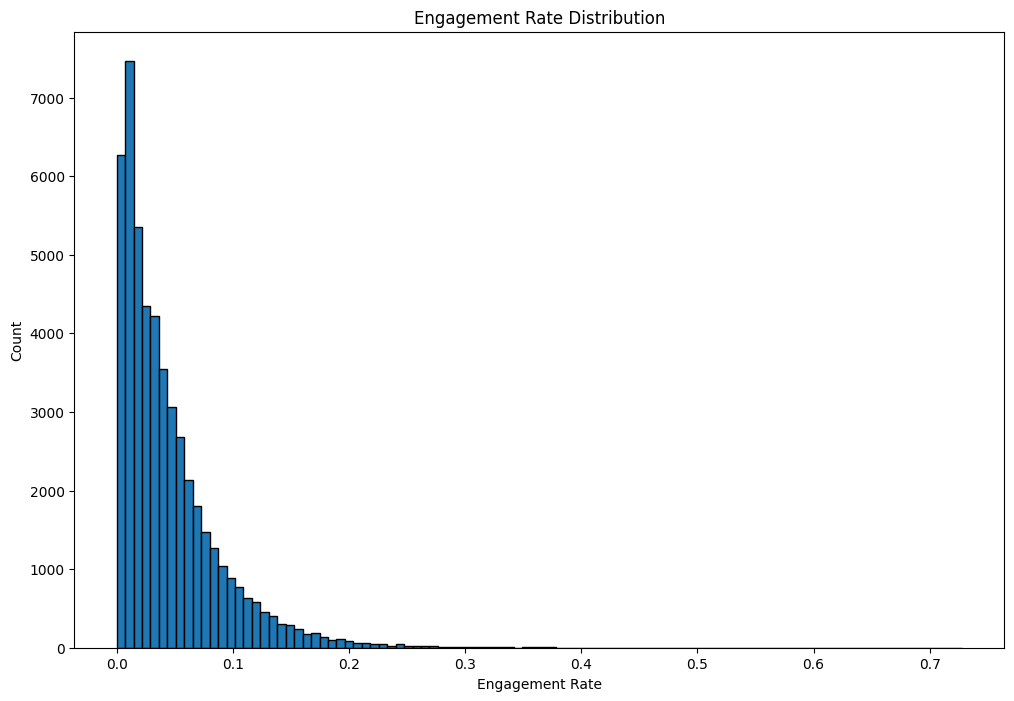

In [ ]:
# Engagement Rate Distribution
fig, ax = plt.subplots(figsize=(12, 8))
ax.hist(youtube_videos['engagement_rate_raw'], bins=100, edgecolor='black')
ax.set_title("Engagement Rate Distribution")
ax.set_xlabel("Engagement Rate")
ax.set_ylabel("Count")
plt.show()

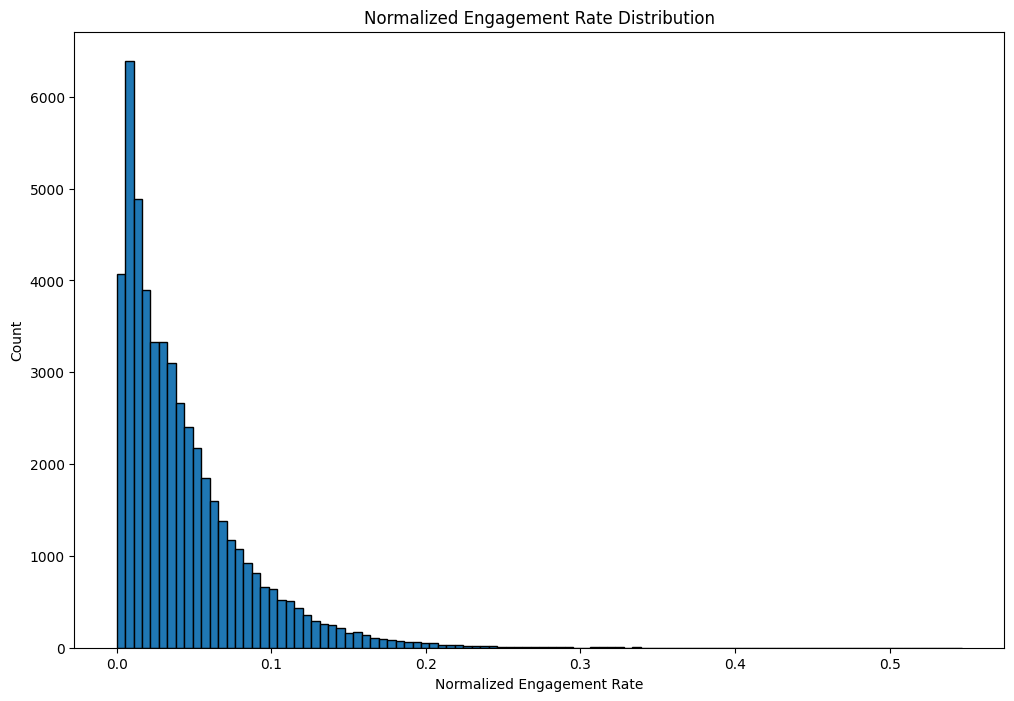

In [ ]:
# Normalized Engagement Rate Distribution
fig, ax = plt.subplots(figsize=(12, 8))
ax.hist(youtube_videos['engagement_rate_log'], bins=100, edgecolor='black')
ax.set_title("Normalized Engagement Rate Distribution")
ax.set_xlabel("Normalized Engagement Rate")
ax.set_ylabel("Count")
plt.show()

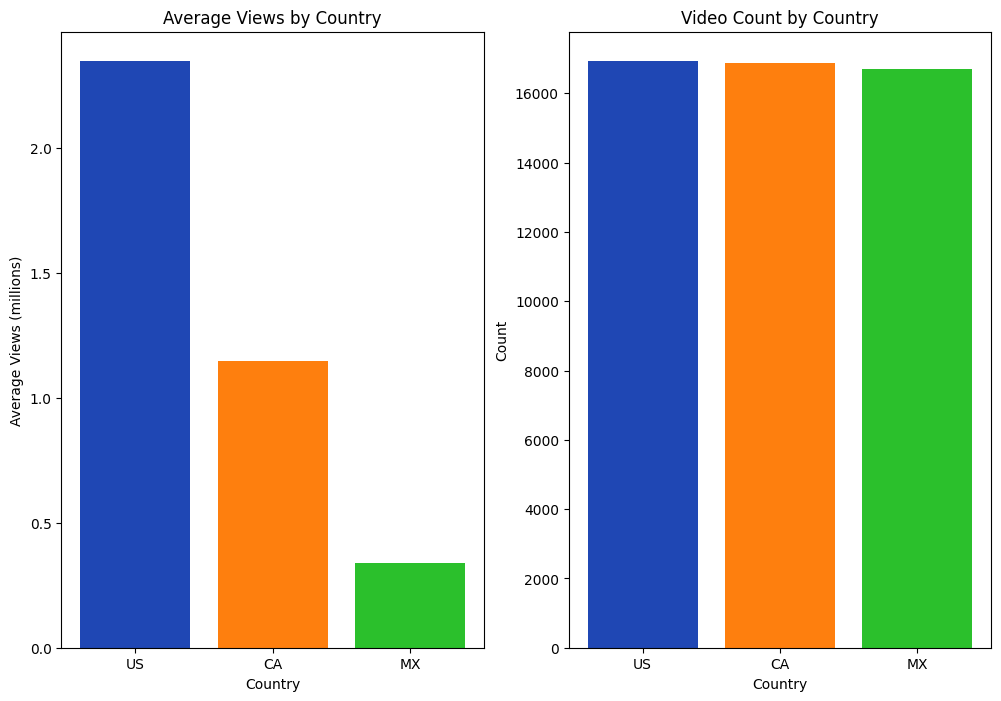

In [ ]:
# Views by Country
fig, ax = plt.subplots(1, 2, figsize=(12, 8))

youtube_by_country = youtube_videos.groupby('country')['views'].mean().sort_values(ascending=False)
ax[0].bar(youtube_by_country.index, youtube_by_country.values / 1e6, color=['#1f47b4','#fe7f0e','#2bc02c'])
ax[0].set_title('Average Views by Country')
ax[0].set_xlabel('Country')
ax[0].set_ylabel('Average Views (millions)')

youtube_country_counts = youtube_videos['country'].value_counts()
ax[1].bar(youtube_country_counts.index, youtube_country_counts.values, color=['#1f47b4','#fe7f0e','#2bc02c'])
ax[1].set_title('Video Count by Country')
ax[1].set_xlabel('Country')
ax[1].set_ylabel('Count')

plt.show()

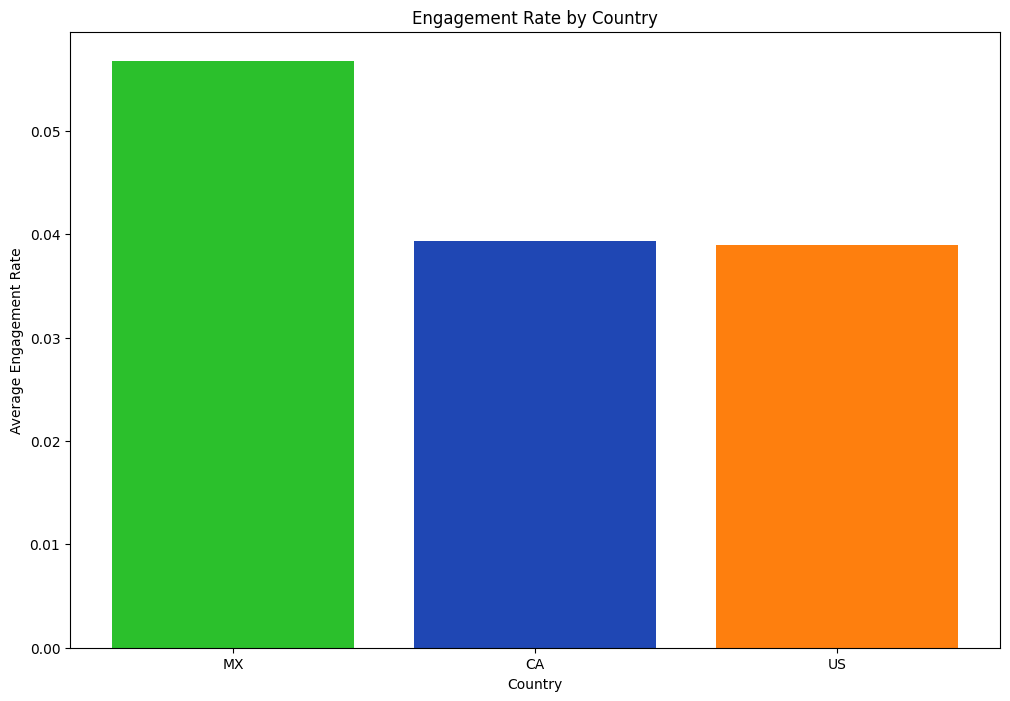

In [ ]:
# Engagement Rate by Country
fig, ax = plt.subplots(figsize = (12, 8))

rate_by_country = youtube_videos.groupby('country')['engagement_rate_raw'].mean().sort_values(ascending=False)
ax.bar(rate_by_country.index, rate_by_country.values, color=['#2bc02c', '#1f47b4','#fe7f0e'])
ax.set_title('Engagement Rate by Country')
ax.set_xlabel('Country')
ax.set_ylabel('Average Engagement Rate')

plt.show()

## Feature Engineering

In [ ]:
# Extract Post Hour
youtube_videos['publish_hour'] = youtube_videos.loc[:, 'publish_time'].dt.hour

# Extract Day of the Week
youtube_videos['publish_day'] = youtube_videos['publish_time'].dt.dayofweek
youtube_videos['publish_day_name'] = youtube_videos['publish_time'].dt.day_name()

In [ ]:
# Determine Tag Count
youtube_videos['tag_count'] = youtube_videos['tags'].apply(lambda x: len(x))

# Determine Title Length
youtube_videos['title_length'] = youtube_videos['title'].apply(lambda x: len(x))

In [ ]:
# Add Other Title Engagement Features
def extract_title_features(title):
    letters = [c for c in title if c.isalpha()]
    
    total_letters = len(letters)
    uppercase_letters = sum(1 for c in letters if c.isupper())
    
    caps_ratio = uppercase_letters / total_letters if total_letters > 0 else 0

    return {
        'title_has_question'   : int('?' in title),
        'title_has_exclamation': int('!' in title),
        'title_has_pipe'       : int('|' in title),
        'title_caps_ratio'     : caps_ratio
    }

title_features = youtube_videos['title'].apply(extract_title_features)
youtube_videos = pd.concat([youtube_videos, pd.DataFrame(title_features.to_list(), index=youtube_videos.index)], axis=1)

In [ ]:

with open('sentiment_data.json', 'r') as sent_file:
    sentiment_df = pd.DataFrame(json.load(sent_file))

with open('desc_sentiment_data.json', 'r') as desc_file:
    desc_sentiment_df = pd.DataFrame(json.load(desc_file))


In [ ]:
"""
# -------------------------------------------------------------------------
# AI USAGE CITATION
# Tool: Claude AI
# Prompt: "Write Python code that utilizes the Hugging Face API
# from torch to analyze the sentiment of a title using a multilingual model"
# Usage: Used the pipeline and GPU settings, but built the rest of the API calls and dataframe concatenation.

import torch
from transformers import pipeline
# Device setup
device = 0
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

# Initialize pipeline
text_pipeline = pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-xlm-roberta-base-sentiment',
    device=0,
    dtype=torch.float16,
    max_length=512
)

# Function to convert scores
def convert_full(res):
    label = res['label']
    return {
      'neg': res['score'] if label == 'negative' else 0.0,
      'neu': res['score'] if label == 'neutral'  else 0.0,
      'pos': res['score'] if label == 'positive' else 0.0
    }

# Reclean titles
titles = youtube_videos['title'].fillna('').astype(str).tolist()

# Run in batches
sentiment_data = []
results = text_pipeline(titles, truncation=True)
sentiment_data.extend([convert_full(r) for r in results])

# Convert to DataFrame columns
sentiment_df = pd.DataFrame(sentiment_data)
"""
# Attach to original dataframe
youtube_videos = youtube_videos.reset_index(drop=True)
youtube_videos[['title_neg', 'title_neu', 'title_pos']] = sentiment_df[['neg', 'neu', 'pos']].values
youtube_videos['title_sentiment'] = youtube_videos['title_pos'] - youtube_videos['title_neg']

print(youtube_videos['title_sentiment'].describe())

count    50531.000000
mean        -0.056567
std          0.376344
min         -0.961517
25%          0.000000
50%          0.000000
75%          0.000000
max          0.945097
Name: title_sentiment, dtype: float64


In [ ]:
"""
with open('sentiment_data.json', 'w') as f:
    json.dump(sentiment_data, f)
"""

In [ ]:
"""
# Run sentiment pipeline on descriptions
descriptions = youtube_videos['description'].fillna('').astype(str).tolist()

desc_sentiment_data = []

desc_pipeline = pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-xlm-roberta-base-sentiment',
    device=0,
    dtype=torch.float32,
    max_length=512
)

for i in range(0, len(descriptions), 64):
    batch = descriptions[i:i+64]
    results = desc_pipeline(batch, truncation=True)
    desc_sentiment_data.extend([convert_full(r) for r in results])

desc_sentiment_df = pd.DataFrame(desc_sentiment_data)
"""
youtube_videos[['description_neg', 'description_neu', 'description_pos']] = desc_sentiment_df[['neg', 'neu', 'pos']].values
youtube_videos['description_sentiment'] = youtube_videos['description_pos'] - youtube_videos['description_neg']

print(youtube_videos['description_sentiment'].describe())

count    50531.000000
mean        -0.023348
std          0.244699
min         -0.959413
25%          0.000000
50%          0.000000
75%          0.000000
max          0.938215
Name: description_sentiment, dtype: float64


In [ ]:
youtube_videos.head(5)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,title_has_pipe,title_caps_ratio,title_neg,title_neu,title_pos,title_sentiment,description_neg,description_neu,description_pos,description_sentiment
0,ugdgAifIOBA,2018-02-02,Why Don't We - Trust Fund Baby (Official Audio),Atlantic Records,10,2018-02-01 05:01:03+00:00,"[music, ""official"", ""music video"", ""atlantic"",...",206028,21951,329,...,0,0.0,0.000000,0.748844,0.000000,0.000000,0.0,0.542841,0.000000,0.000000
1,Gi56dSh8Fq8,2018-06-14,Gourmet Chef Makes A Big Mac Super Fancy,BuzzFeedVideo,22,2018-06-13 18:00:32+00:00,"[mcdonalds, ""big mac"", ""fancy"", ""fast food"", ""...",402418,10070,3303,...,0,0.0,0.000000,0.000000,0.744517,0.744517,0.0,0.465500,0.000000,0.000000
2,7VnEPIBsp20,2018-01-05,Zac Efron Made Michael Jackson Cry! | The Grah...,The Graham Norton Show,24,2017-12-29 15:30:01+00:00,"[Graham Norton, ""Graham Norton Show Official"",...",1437372,33670,1626,...,1,0.0,0.627003,0.000000,0.000000,-0.627003,0.0,0.000000,0.511228,0.511228
3,vvuj7-xspns,2018-01-08,JuJu Smith-Schuster Pranks Steelers Fans - Und...,JuJu Smith-Schuster,24,2018-01-05 18:59:22+00:00,"[JuJu Smith-Schuster, ""JuJu Smith"", ""JuJu"", ""J...",417790,13878,346,...,0,0.0,0.000000,0.627347,0.000000,0.000000,0.0,0.506049,0.000000,0.000000
4,0ycLaWymtKk,2017-12-25,Merry Christmas in Dominoes! 🎅🏻 (Christmas Card),Hevesh5,24,2017-12-23 18:00:00+00:00,"[christmas, ""christmas domino"", ""merry christm...",816662,16873,468,...,0,0.0,0.000000,0.000000,0.746055,0.746055,0.0,0.378812,0.000000,0.000000


In [ ]:
"""
with open('desc_sentiment_data.json', 'w') as f:
    json.dump(desc_sentiment_data, f)
"""

## Final Exploratory Data Analysis

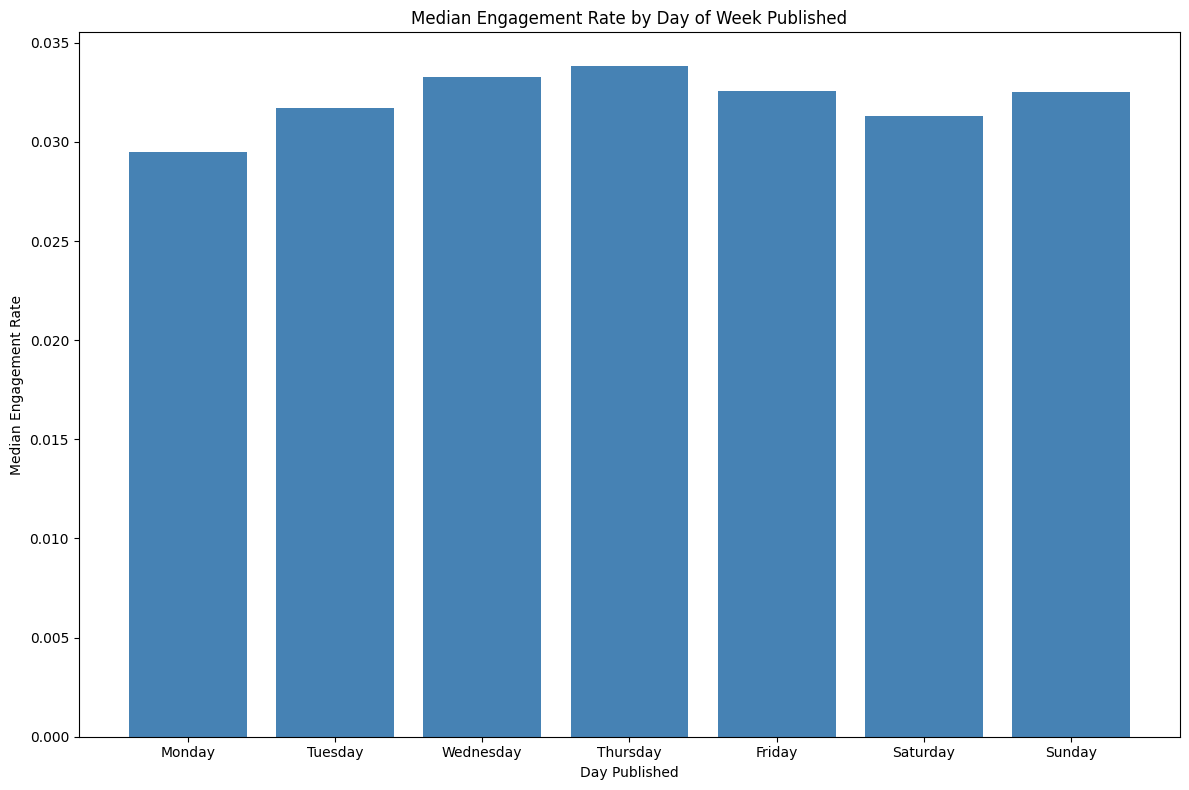

In [ ]:
# Engagement Rate by Publish Day Name
engagement_by_day = youtube_videos.groupby('publish_day_name')['engagement_rate_raw'].median().sort_values(ascending=False)

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
engagement_by_day = (youtube_videos.groupby('publish_day_name')['engagement_rate_raw']
           .median().reindex(day_order))

plt.figure(figsize=(12, 8))
plt.bar(engagement_by_day.index, engagement_by_day.values, color='steelblue')
plt.title('Median Engagement Rate by Day of Week Published')
plt.xlabel('Day Published')
plt.ylabel('Median Engagement Rate')
plt.tight_layout()
plt.show()

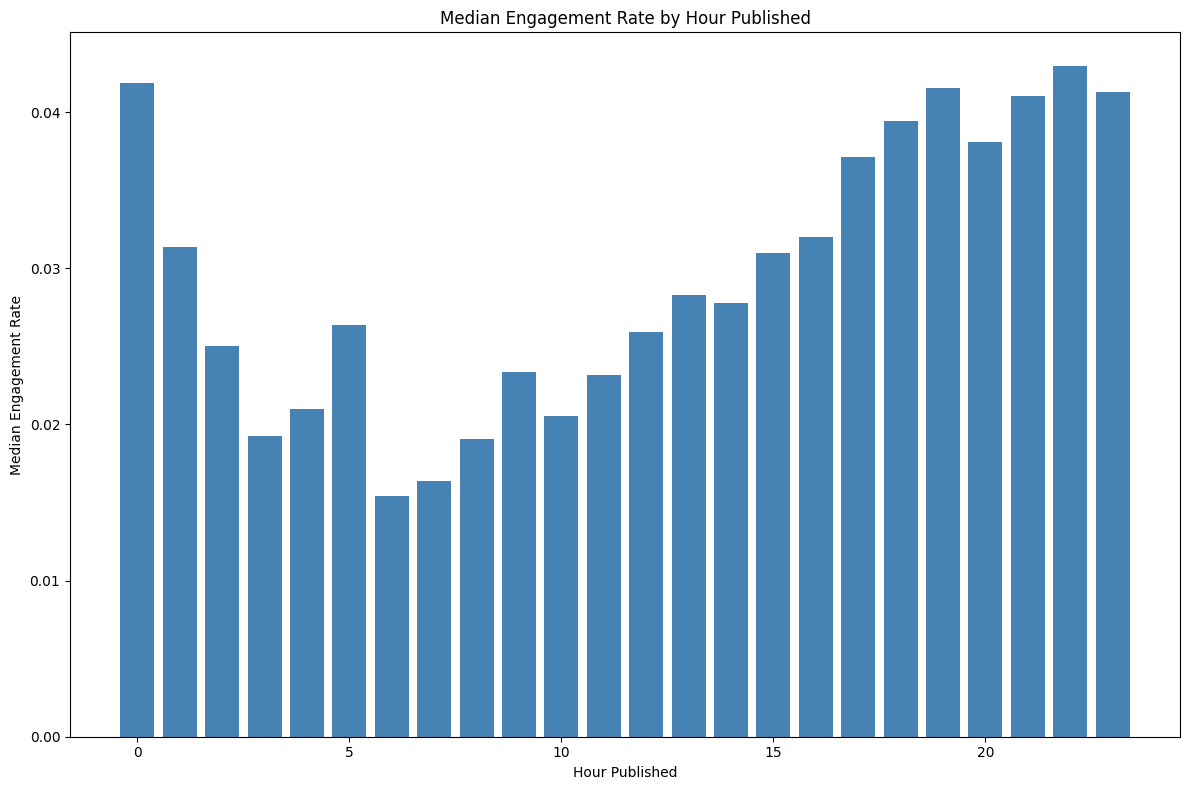

In [ ]:
# Engagement Rate by Publish Hour
engagement_by_hour = youtube_videos.groupby('publish_hour')['engagement_rate_raw'].median().sort_values(ascending=False)

hour_order = [str(i) for i in range(24)]
engagement_by_hour = (youtube_videos.groupby('publish_hour')['engagement_rate_raw']
           .median())

plt.figure(figsize=(12, 8))
plt.bar(engagement_by_hour.index, engagement_by_hour.values, color='steelblue')
plt.title('Median Engagement Rate by Hour Published')
plt.xlabel('Hour Published')
plt.ylabel('Median Engagement Rate')
plt.tight_layout()
plt.show()

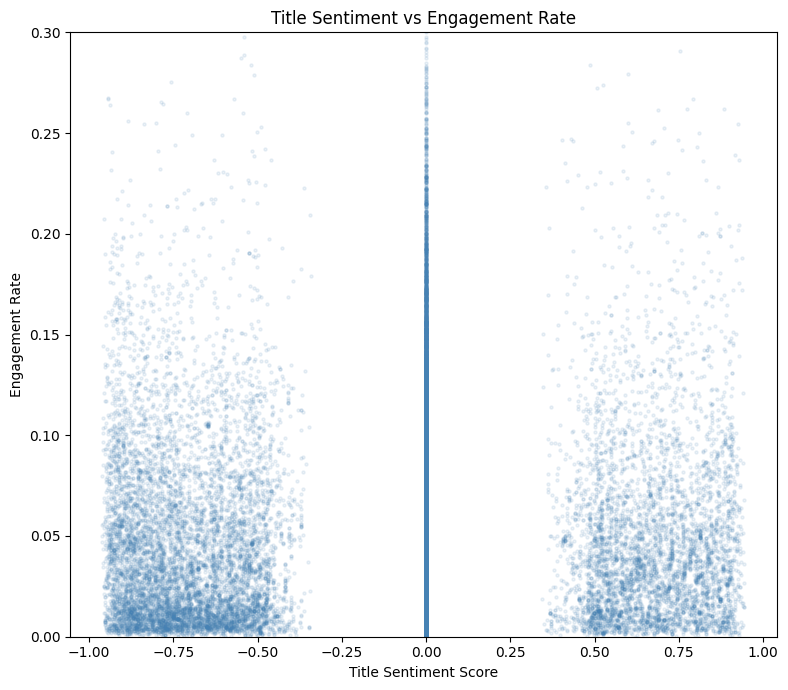

In [ ]:
# Correlation between Title Sentiment and Engagement
plt.figure(figsize=(8, 7))
plt.scatter(youtube_videos['title_sentiment'], youtube_videos['engagement_rate_raw'],
            alpha=0.1, s=5, color='steelblue')
plt.ylim(0, 0.3)
plt.xlabel('Title Sentiment Score')
plt.ylabel('Engagement Rate')
plt.title('Title Sentiment vs Engagement Rate')
plt.tight_layout()
plt.show()

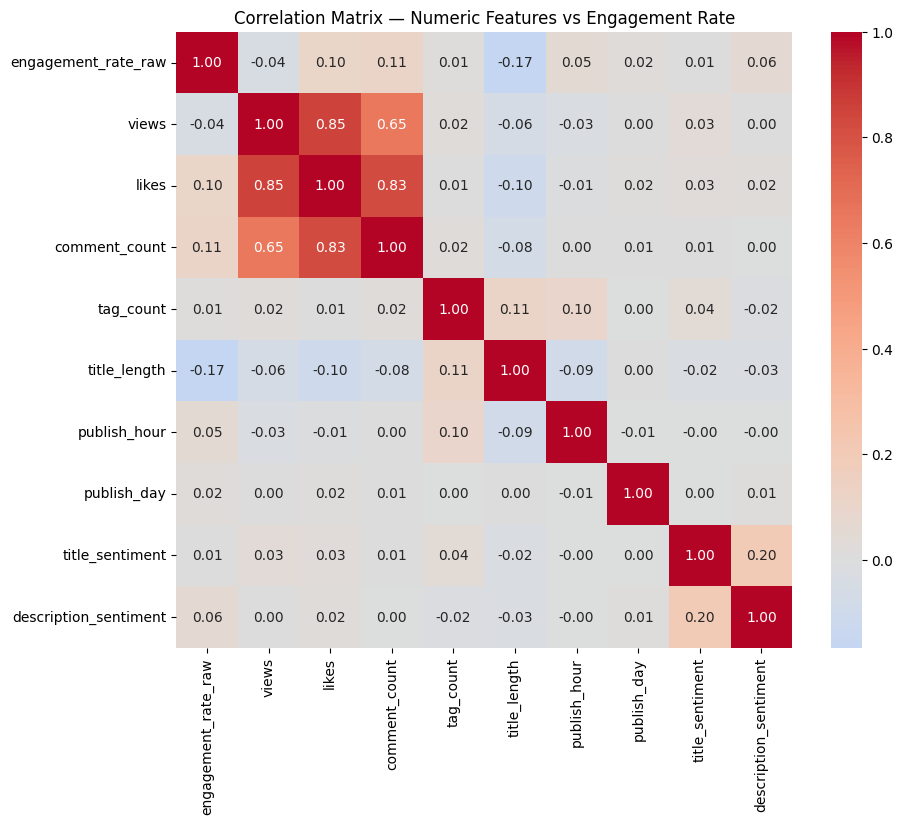

In [ ]:
# General Correlation Matrix
corr_cols = ['engagement_rate_raw', 'views', 'likes', 'comment_count',
             'tag_count', 'title_length', 'publish_hour', 'publish_day',
             'title_sentiment', 'description_sentiment']
corr_matrix = youtube_videos[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True)
plt.title('Correlation Matrix — Numeric Features vs Engagement Rate')
plt.show()

## Model Preparation

In [ ]:
# Select features to use
features = [
    'category_id'
    'comments_disabled',
    'publish_hour',
    'publish_day',
    'tag_count',
    'title_length',
    'title_sentiment',
    'description_sentiment',
    'country',
    'title_has_question',
    'title_has_exclamation',
    'title_has_pipe',
    'title_caps_ratio'
]

In [ ]:
# Separate Features from Labels
X = youtube_videos[features]
y = youtube_videos["engagement_rate_log"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

In [ ]:
# Selected the following numeric columns
numeric_columns = ['title_sentiment',
                   'description_sentiment',
                   'tag_count',
                   'title_length',
                   'title_has_question',
                   'title_has_exclamation',
                   'title_has_pipe',
                   'title_caps_ratio']

# Selected the following categorical columns
categorical_columns = ['category_id', 'comments_disabled', 'publish_hour', 'publish_day', 'country']

In [ ]:
# Create pipeline
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

# Creates numeric pipeline
# Scales the data to reduce dimensionality
numeric_pipeline = make_pipeline(
    StandardScaler()
)

# Creates categorical pipeline
# One Hot Encodes Categorical Features
categorical_pipeline = make_pipeline(
    OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
)

# Uses ColumnTransformers to pass the data through the different pipelines to handle the variety of data types
column_transformer = ColumnTransformer(
    [('num', numeric_pipeline, numeric_columns),
     ('cat', categorical_pipeline, categorical_columns)]
)

# Fit and transform the data through the ColumnTransformers
X_train_transformed = column_transformer.fit_transform(X_train, y_train)
X_test_transformed = column_transformer.transform(X_test)

## Model Creation

In [ ]:
# Create Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train_transformed, y_train)

LinearRegression()

In [ ]:
# RandomizedSearchCV for Random Forest Regression
rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 20],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt'],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(),
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
rf_search.fit(X_train_transformed, y_train)

print("Best params:", rf_search.best_params_)
print("Best CV R²: ", rf_search.best_score_.round(4))

best_rf_model = rf_search.best_estimator_

# RandomizedSearchCV for XGBoost
xgb_param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(tree_method='hist'),
    param_distributions=xgb_param_grid,
    n_iter=30,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
xgb_search.fit(X_train_transformed, y_train)

print("Best params:", xgb_search.best_params_)
print("Best CV R²: ", xgb_search.best_score_.round(4))

best_xgb_model = xgb_search.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=20. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV R²:  0.3488
Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'subsample': 0.8, 'reg_alpha': 0.1, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV R²:  0.2729


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 0.2774 - mae: 0.3683 - val_loss: 0.0078 - val_mae: 0.0704
Epoch 2/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0526 - mae: 0.1719 - val_loss: 0.0069 - val_mae: 0.0659
Epoch 3/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0243 - mae: 0.1152 - val_loss: 0.0042 - val_mae: 0.0484
Epoch 4/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0137 - mae: 0.0853 - val_loss: 0.0034 - val_mae: 0.0453
Epoch 5/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0085 - mae: 0.0664 - val_loss: 0.0026 - val_mae: 0.0378
Epoch 6/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0062 - mae: 0.0562 - val_loss: 0.0023 - val_mae: 0.0375
Epoch 7/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0048 - mae: 0.0493 - val_loss: 0.0019 - val_mae: 0.0326
Epoch 8/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0039 - mae: 0.0446 - val_loss: 0.0018 - val_mae: 0.0326
Epoch 9/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms

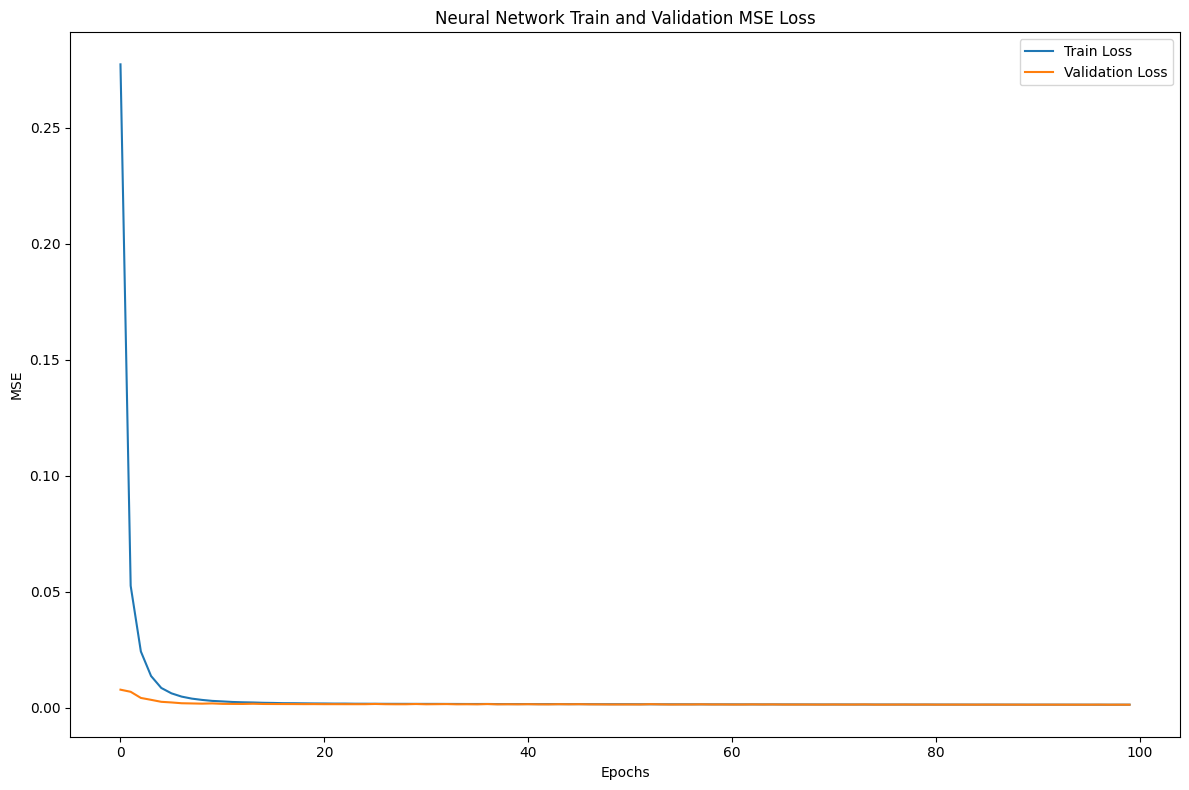

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,389 (189.02 KB)

 Trainable params: 16,001 (62.50 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 32,004 (125.02 KB)

In [ ]:
input_dim = X_train_transformed.shape[1]

nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='linear') # Changed from Dense(32, activation='relu') to Dense(1, activation='linear')
])

nn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

hist = nn_model.fit(
    X_train_transformed, y_train,
    validation_data=(X_test_transformed, y_test),
    batch_size=256,
    epochs=100,
    verbose=1
)

plt.figure(figsize=(12,8))
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Validation Loss')
plt.title("Neural Network Train and Validation MSE Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

nn_model.summary()

## Model Evaluation

In [ ]:
# Collect results from all four models
models = {
    'Random Forest': best_rf_model,
    'XGBoost': best_xgb_model,
    'Linear Regression': linear_model,
    'Neural Network': nn_model,
}

print(f"{'Model':<25} {'R² (raw)':>10} {'MAE (raw)':>12} {'RMSE (raw)':>12}")
print("-" * 68)

for name, model in models.items():
    # Suppress verbose output for Neural Network predict method
    if name == 'Neural Network':
        y_pred_log = model.predict(X_test_transformed, verbose=0)
    else:
        y_pred_log = model.predict(X_test_transformed)

    # Ensure y_pred_log is flattened only if it's a Neural Network
    if name == 'Neural Network' and y_pred_log.ndim > 1:
        y_pred_log = y_pred_log.flatten()

    y_pred_raw = np.expm1(y_pred_log)
    y_test_raw = np.expm1(y_test)
    r2_raw   = r2_score(y_test_raw, y_pred_raw)
    mae_raw  = mean_absolute_error(y_test_raw, y_pred_raw)
    rmse_raw = root_mean_squared_error(y_test_raw, y_pred_raw)

    print(f"{name:<24} {r2_raw:>10.4f} {mae_raw:>12.4f} {rmse_raw:>12.4f}")

Model                       R² (raw)    MAE (raw)   RMSE (raw)
--------------------------------------------------------------------
Random Forest                0.3669       0.0206       0.0354
XGBoost                      0.2825       0.0244       0.0377
Linear Regression            0.1416       0.0288       0.0412
Neural Network               0.2066       0.0267       0.0396


In [ ]:
"""
# Open and Load Best Model
with open("youtube_model.pkl", "rb") as f:
    best_model = pkl.load(f)

with open("column_transformer.pkl", "rb") as f:
    column_transformer = pkl.load(f)

with open("engagement_stats.pkl", "rb") as f:
    engagement_stats = pkl.load(f)
"""

'\n# Open and Load Best Model\nwith open("youtube_model.pkl", "rb") as f:\n    best_model = pkl.load(f)\n\nwith open("column_transformer.pkl", "rb") as f:\n    column_transformer = pkl.load(f)\n\nwith open("engagement_stats.pkl", "rb") as f:\n    engagement_stats = pkl.load(f)\n'

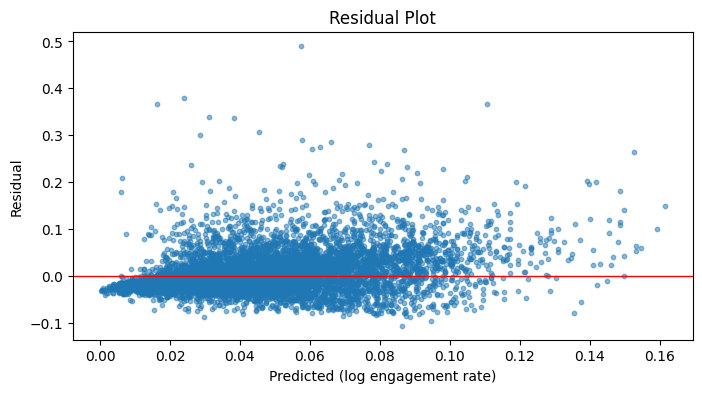

In [ ]:
# Residual plot for the best model
best_model = best_rf_model

y_pred = best_model.predict(X_test_transformed)
residuals = y_test_raw - y_pred_raw

plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.5, s=10)
plt.axhline(0, color='red', linewidth=1)
plt.xlabel("Predicted (log engagement rate)")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [ ]:
with open("youtube_model.pkl", "wb") as f:
    pkl.dump(best_model, f)

with open("column_transformer.pkl", "wb") as f:
    pkl.dump(column_transformer, f)

print("Model and transformer saved successfully.")

Model and transformer saved successfully.


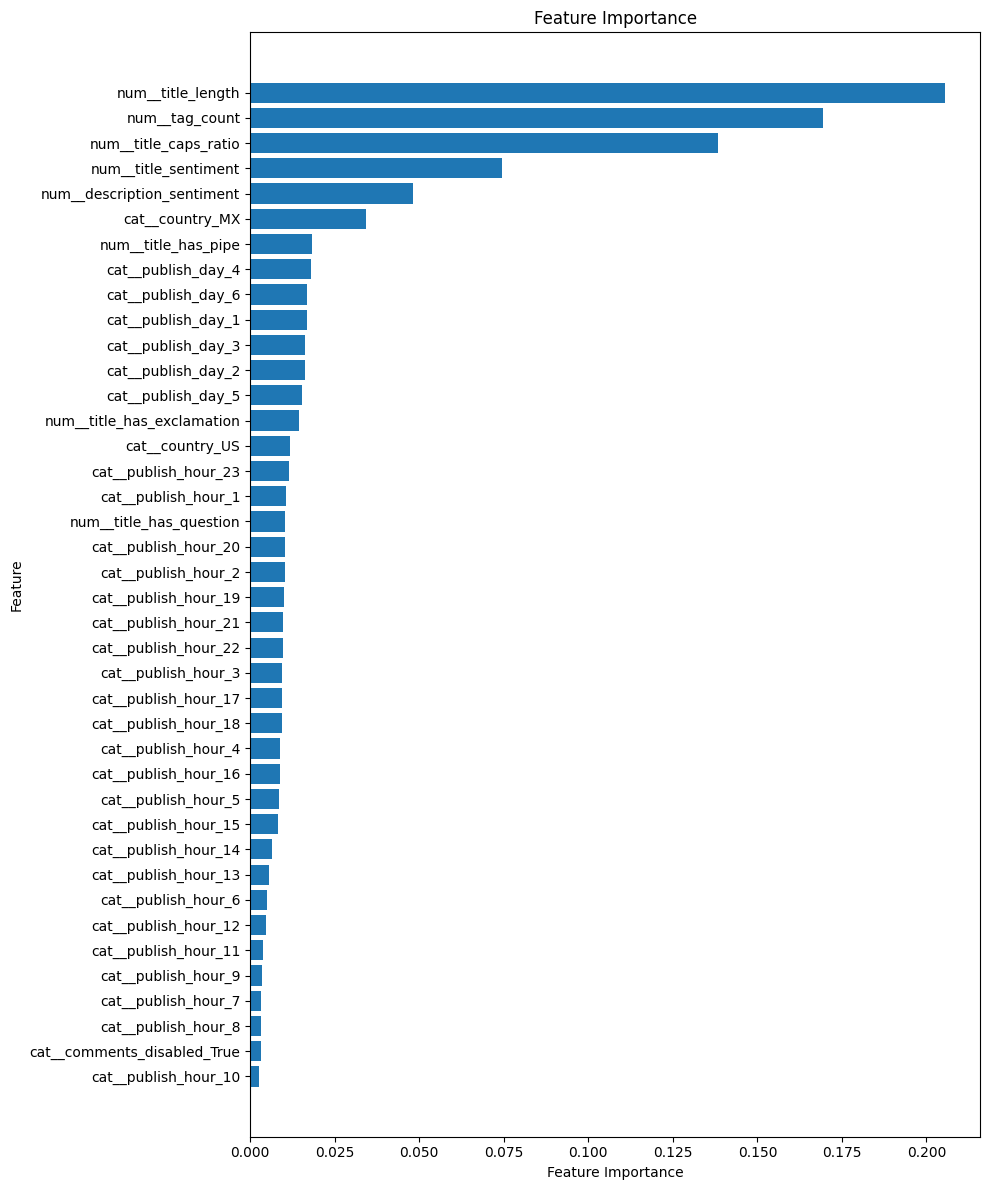

In [ ]:
# View Feature Importances
feature_importance = best_model.feature_importances_
features = column_transformer.get_feature_names_out()

# Sort indices by importance (descending)
sorted_idx = np.argsort(feature_importance)

sorted_importances = feature_importance[sorted_idx]
sorted_features = features[sorted_idx]

# Plot
plt.figure(figsize=(10, 12))
plt.barh(sorted_features, sorted_importances)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

## Model Utilization and Prep for UI

In [ ]:
y_train_raw = np.expm1(y_train)

engagement_stats = {
    'mean': float(y_train_raw.mean()),
    'std':  float(y_train_raw.std()),
    'p1':   float(np.percentile(y_train_raw, 1)),
    'p99':  float(np.percentile(y_train_raw, 99)),
    'percentiles': np.percentile(y_train_raw, np.arange(0, 101))
}

with open("engagement_stats.pkl", "wb") as f:
    pkl.dump(engagement_stats, f)

print("Stats saved.")
print(f"  Mean engagement rate: {engagement_stats['mean']:.4f}")
print(f"  Std:                  {engagement_stats['std']:.4f}")
print(f"  1st–99th percentile:  {engagement_stats['p1']:.4f} – {engagement_stats['p99']:.4f}")

Stats saved.
  Mean engagement rate: 0.0449
  Std:                  0.0444
  1st–99th percentile:  0.0018 – 0.2023


In [ ]:
# Pipeline setup
device = 0 if torch.cuda.is_available() else -1
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    device=device,
    dtype=torch.float32,
)

# Sentiment setup
def get_sentiment(text):
    result = sentiment_pipeline(text[:512], truncation=True)[0]
    label  = result["label"]
    score  = result["score"]
    pos = score if label == "positive" else 0.0
    neg = score if label == "negative" else 0.0
    return pos - neg


# Engineer inputs
dt = datetime.strptime(publish_dt, "%Y-%m-%d %H:%M")
publish_hour = dt.hour
publish_day = dt.weekday()
tag_count = len([t.strip() for t in raw_tags.split(",") if t.strip()])
title_length = len(title)

title_sentiment = get_sentiment(title)
description_sentiment = get_sentiment(description)

words = title.split()
title_has_question    = int('?' in title)
title_has_exclamation = int('!' in title)
title_has_pipe        = int('|' in title)
title_caps_ratio      = sum(1 for w in words if w.isupper() and len(w) > 1) / max(len(words), 1)

new_data = pd.DataFrame([{
    "title_sentiment"      : title_sentiment,
    "description_sentiment": description_sentiment,
    "tag_count"            : tag_count,
    "title_length"         : title_length,
    "category_id"          : category_id,
    "comments_disabled"    : comments_disabled,
    "publish_hour"         : publish_hour,
    "publish_day"          : publish_day,
    "country"              : country,
    "title_has_question"   : title_has_question,
    "title_has_exclamation": title_has_exclamation,
    "title_has_pipe"       : title_has_pipe,
    "title_caps_ratio"     : title_caps_ratio
}])

# Predict
new_data_transformed = column_transformer.transform(new_data)
log_pred  = best_model.predict(new_data_transformed)[0]
predicted_rate = np.expm1(log_pred)

# Normalize against trending video distribution
z_score = (predicted_rate - engagement_stats['mean']) / engagement_stats['std']

percentile_rank = int(np.searchsorted(engagement_stats['percentiles'], predicted_rate))
percentile_rank = max(0, min(100, percentile_rank))

p1, p99 = engagement_stats['p1'], engagement_stats['p99']
minmax  = float(np.clip((predicted_rate - p1) / (p99 - p1) * 100, 0, 100))



NameError: name 'torch' is not defined